# Joint Pertub-seq perturbations analysis

In [9]:
import os 
import sys
sys.path.append('../../..')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scanpy as sc

from causarray import prep_causarray_data, fit_gcate, LFC

The original data of Jin et al 2020 can be downloaded from the Broad single cell portal (https://singlecell.broadinstitute.org/single_cell/study/SCP1184).
Here, we just use a subset of the data to demonstrate the workflow of the analysis.

In [10]:
adata = sc.read_h5ad('perturbseq-exneu.h5ad')
adata

AnnData object with n_obs × n_vars = 2926 × 3221
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'nGene', 'nUMI', 'Cluster', 'Batch', 'CellType', 'Perturbation', 'isKey', 'isAnalysed', 'SCRUBLET'

For running causarray, we require the following inputs:

- `Y`: the cell-by-gene gene expression matrix.
- `A`: the cell-by-condition binary matrix of the perturbation/treatment conditions.
- `X, X_A`: (optional) the cell-by-covariate matrix of the covariates of interest for outcome and propensity models.

Here, `Y` and `A` can be dataframes.

In [11]:
Y = pd.DataFrame(adata.X.copy(), columns=adata.var.index)
A = pd.get_dummies(adata.obs['Perturbation'], columns=['Perturbation'], drop_first=False).drop(columns=['GFP'])

Y, A, X, X_A = prep_causarray_data(Y, A)
a = A.shape[1]
a

29

### Number of nonlinear factors

We can estimate the number of nonlinear factors using the following function.

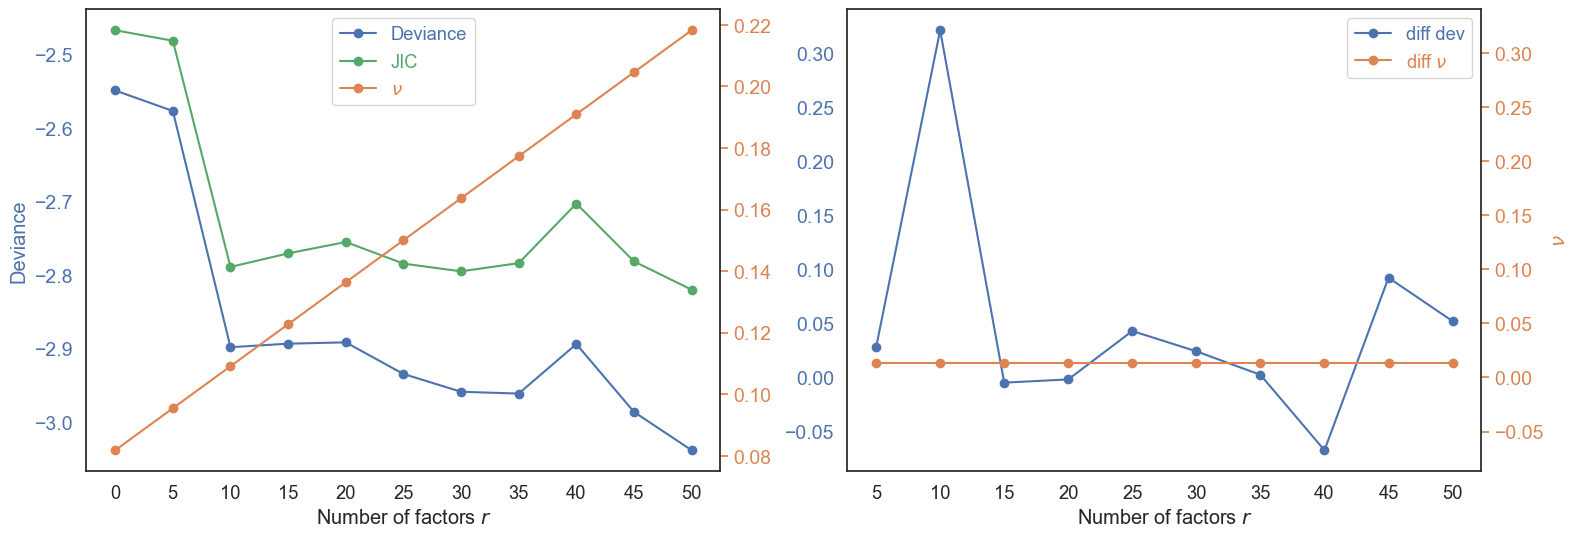

In [12]:
from causarray import estimate_r, plot_r
# df_r = estimate_r(Y, X, A, np.arange(5,55,5))
# df_r.to_csv('perturbseq-r.csv', index=False)
df_r = pd.read_csv('perturbseq-r.csv')
fig = plot_r(df_r)

### Estimate unmeasured confounders

We first apply gcate to estimate unmeasured confounders.

In [14]:
r = 10
res_1, res_2 = fit_gcate(Y, X, A, r, verbose=True,
    kwargs_es_1=dict(rel_tol=2e-4, max_iters=30),
    kwargs_es_2=dict(rel_tol=2e-4, max_iters=30),
)
U = res_2['U']
print(f"\nStep 1  -- epochs: {res_1['n_iter']},  best NLL: {min(res_1['hist']):.6f}")
print(f"Step 2  -- epochs: {res_2['n_iter']},  best NLL: {min(res_2['hist']):.6f}")

{'d': 30, 'n': 2926, 'p': 3221, 'r': 10}
'Estimating initial latent variables with GLMs...'
'Fitting nb GLM (fast)...'
'Estimating initial coefficients with GLMs...'
'Fitting nb GLM (fast)...'
{'kwargs_es': {'max_iters': 30,
               'patience': 5,
               'rel_tol': 0.0002,
               'tolerance': 0.0,
               'warmup': 0},
 'kwargs_glm': {'disp_glm': array([ 1.11673516,  1.06870944,  1.16716468, ..., 12.58818245,
       16.46897663,  1.70852614], shape=(3221,)),
                'family': 'nb',
                'size_factor': array([0.53193358, 0.87362742, 1.2235467 , ..., 0.5593801 , 0.73025856,
       0.77857223], shape=(2926,))},
 'kwargs_ls': {'C': 1000.0,
               'alpha': 0.1,
               'beta': 0.5,
               'max_iters': 20,
               'recheck_interval': 10,
               'sparsity_boost': 2.0,
               'sparsity_threshold': 0.5,
               'tol': 0.0001,
               'tol_cell': 0.0001,
               'tol_gene': 0.0001,

 97%|█████████▋| 29/30 [00:48<00:01,  1.69s/it, Early stopped. Best Epoch: 23. Best Metric: 1.706115.]


{'d': 30, 'n': 2926, 'p': 3221, 'r': 10}
{'kwargs_es': {'max_iters': 30,
               'patience': 5,
               'rel_tol': 0.0002,
               'tolerance': 0.0,
               'warmup': 0},
 'kwargs_glm': {'disp_glm': array([ 1.11673516,  1.06870944,  1.16716468, ..., 12.58818245,
       16.46897663,  1.70852614], shape=(3221,)),
                'family': 'nb',
                'size_factor': array([0.53193358, 0.87362742, 1.2235467 , ..., 0.5593801 , 0.73025856,
       0.77857223], shape=(2926,))},
 'kwargs_ls': {'C': 1000.0,
               'alpha': 0.1,
               'beta': 0.5,
               'max_iters': 20,
               'recheck_interval': 10,
               'sparsity_boost': 2.0,
               'sparsity_threshold': 0.5,
               'tol': 0.0001,
               'tol_cell': 0.0001,
               'tol_gene': 0.0001,
               'warmup_iters': 0}}
'Fitting GCATE (step 2)...'


100%|██████████| 30/30 [00:50<00:00,  1.68s/it, nll=1.72]


Step 1  -- epochs: 29,  best NLL: 1.705777
Step 2  -- epochs: 29,  best NLL: 1.722559


### Estimate log-fold change based on counterfactuals

Next, we apply causarray to estimate the causal effects of perturbations on gene expression.

In [15]:
offsets = np.log(res_2['kwargs_glm']['size_factor']) # use the precomputed size factors
df_res, estimation = LFC(Y, np.c_[X, U], A, np.c_[X_A, U], offset=offsets, usevar='pooled', verbose=True)

'Estimating LFC...'
{'a': 29, 'd': 11, 'd_A': 12, 'estimands': 'LFC', 'n': 2926, 'p': 3221}
{'C': 1.0,
 'class_weight': 'balanced',
 'fit_intercept': False,
 'random_state': 0,
 'verbose': False}
{'offset': array([-0.63123664, -0.13510128,  0.20175377, ..., -0.58092607,
       -0.31435661, -0.25029351], shape=(2926,)),
 'random_state': 0,
 'verbose': True}
'Fit propensity score models...'
'Fit outcome models...'
'Fitting nb GLM (fast)...'
'Estimating AIPW mean...'


100%|██████████| 29/29 [00:02<00:00, 13.75it/s]


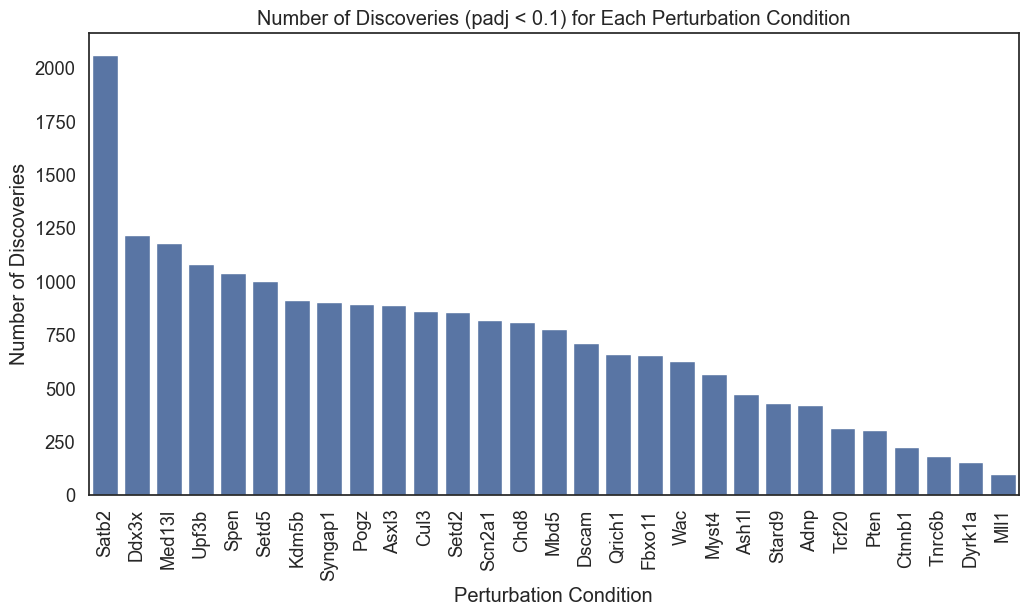

Total significant gene-perturbation pairs (padj < 0.1): 21,102
Perturbation  Count
       Satb2   2061
       Ddx3x   1215
      Med13l   1181
       Upf3b   1081
        Spen   1039
       Setd5    999
       Kdm5b    911
     Syngap1    902
        Pogz    893
       Asxl3    887
        Cul3    863
       Setd2    858
      Scn2a1    819
        Chd8    811
        Mbd5    775
       Dscam    711
      Qrich1    660
      Fbxo11    654
         Wac    628
       Myst4    564
       Ash1l    472
      Stard9    430
        Adnp    421
       Tcf20    313
        Pten    301
      Ctnnb1    224
      Tnrc6b    182
      Dyrk1a    152
        Mll1     95


In [16]:
# Filter the results for significant discoveries
significant_discoveries = df_res[df_res['padj'] < 0.1]

# Count the number of discoveries for each perturbation condition
discovery_counts = significant_discoveries['trt'].value_counts().reset_index()
discovery_counts.columns = ['Perturbation', 'Count']

# Plot the number of discoveries for each perturbation condition
plt.figure(figsize=(12, 6))
sns.barplot(data=discovery_counts, x='Perturbation', y='Count')
plt.xticks(rotation=90)
plt.title('Number of Discoveries (padj < 0.1) for Each Perturbation Condition')
plt.xlabel('Perturbation Condition')
plt.ylabel('Number of Discoveries')
plt.show()
print(f"Total significant gene-perturbation pairs (padj < 0.1): {len(significant_discoveries):,}")
print(discovery_counts.to_string(index=False))

We can also inspect the distribution of propensity scores, to make sure the doubly-robust estimation procedure is reliable. 

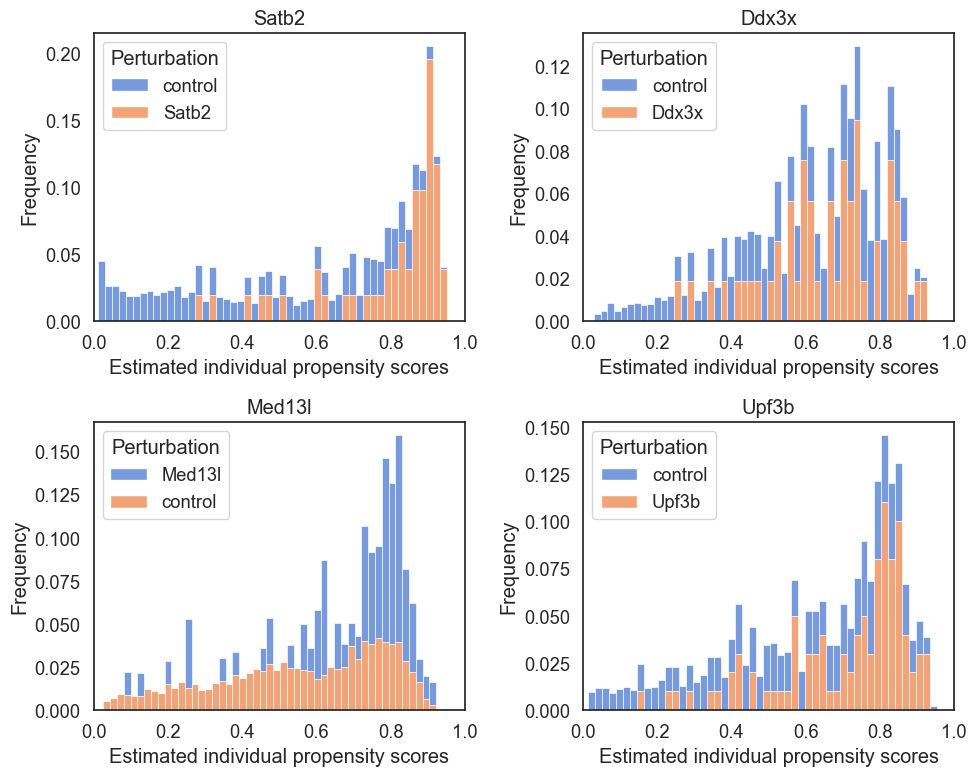

In [17]:
sns.set(font_scale=1.2, style="white")
fig, axes = plt.subplots(2,2,figsize=(10,8))
for i in range(2):
    for j in range(2):
        pert = discovery_counts['Perturbation'][i*2+j]
        a = np.where(A.columns == pert)[0][0]
        _df = pd.DataFrame({
            'value': estimation['pi_hat'][:,a],
            'Perturbation': ['control' if i==0 else pert for i in A.values[:,a]]
        })
        sns.histplot(data=_df, x='value', hue="Perturbation",  common_norm=False,
            multiple='stack', palette='muted', bins=50, stat="probability", ax=axes[i,j])
        axes[i,j].set_xlim([0,1])
        axes[i,j].set_xlabel('Estimated individual propensity scores')
        axes[i,j].set_ylabel('Frequency')
        axes[i,j].set_title(f'{pert}')
fig.tight_layout()
fig.savefig('perturbseq-ps.pdf', bbox_inches='tight', dpi=300)

We observe extreme values only for *Satb2*, which could lead to slightly overconfident estimates. Overall, the distributions of propensity scores are reasonable for most perturbation conditions.